In [ ]:
%reload_ext autoreload
%autoreload 2

import numpy as np
from tqdm import trange
from flygym.compose import ActuatorType
from miniproject.simulation import MiniprojectSimulation
from submission.controller import Controller

sim = MiniprojectSimulation(level=2, seed=2)
controller = Controller(sim)

print("Le fly a-t-il enable_vision ?")

# Test si on peut récupérer les ommatidies
try:
    readouts = sim.get_ommatidia_readouts(sim.fly.name)
    print(f"✓ Vision active ! Shape: {readouts.shape}")
except Exception as e:
    print(f"✗ Vision désactivée : {e}")

# Check la position de la banane et d'éventuels obstacles
print(f"\nBanane : {sim.world.banana_xy}")
print(f"Attributs du monde : {[a for a in dir(sim.world) if 'obstacle' in a.lower() or 'pillar' in a.lower() or 'blade' in a.lower()]}")

# Position de la banane (la cible)
target_pos = np.array(sim.world.banana_xy)
print(f"🍌 Banane en {target_pos}")



for step in trange(100000):
    joint_angles, adhesion = controller.step(sim)
    sim.set_actuator_inputs(sim.fly.name, ActuatorType.POSITION, joint_angles)
    sim.set_actuator_inputs(sim.fly.name, ActuatorType.ADHESION, adhesion)
    sim.step()
    sim.render_as_needed()

print(f"Position finale : {sim.mj_data.body(f'{sim.fly.name}/').xpos[:2]}")

sim.renderer.show_in_notebook()

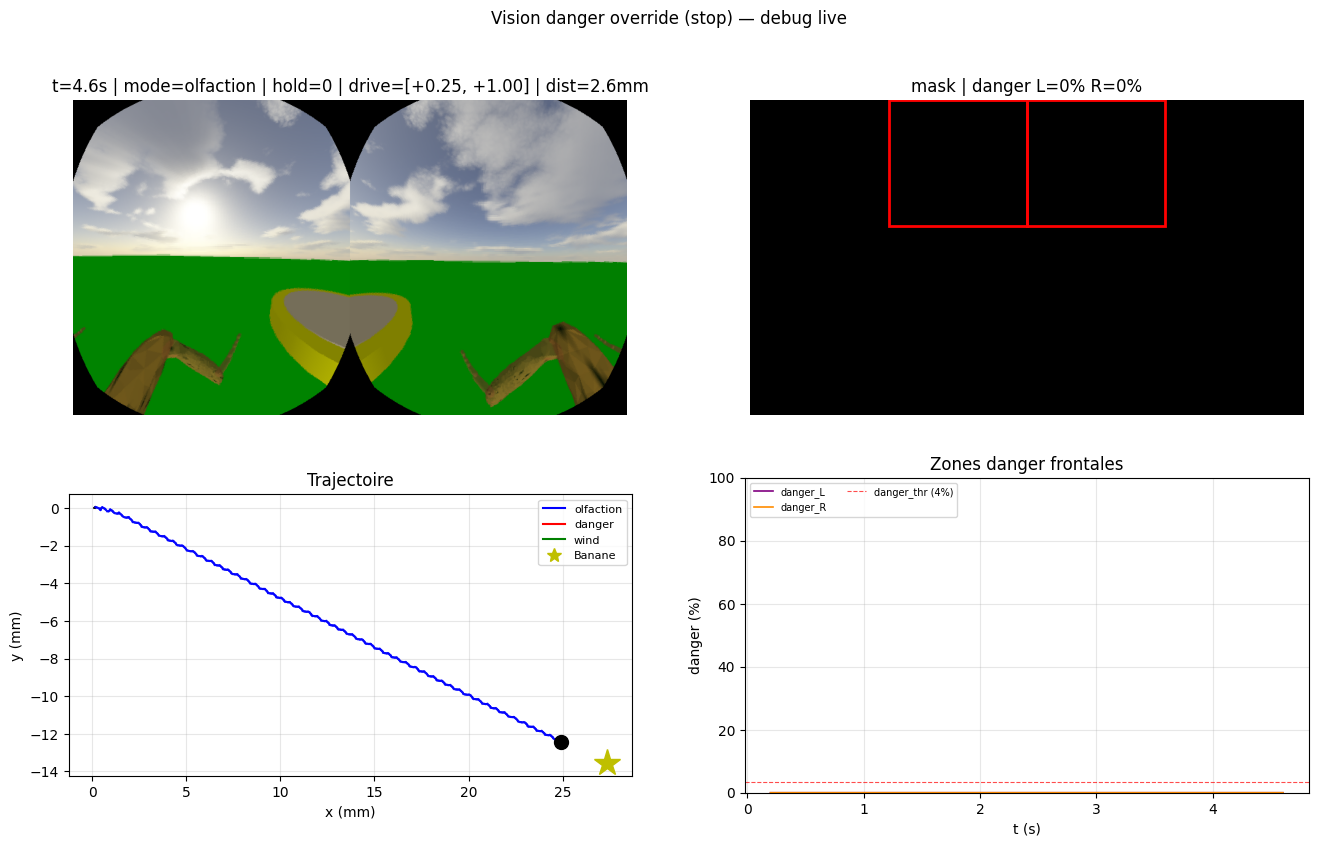

 45%|████▌     | 45044/100000 [00:15<00:18, 2967.26it/s]

Odor L=1.176e-05 | R=1.159e-05
Odor L=1.220e-05 | R=1.215e-05
Odor L=1.280e-05 | R=1.292e-05
Odor L=1.351e-05 | R=1.353e-05
Odor L=1.429e-05 | R=1.412e-05
✅ Banane atteinte à t=4.50s !


nmf/backcam This browser does not support the video tag.


birdeyecam This browser does not support the video tag.


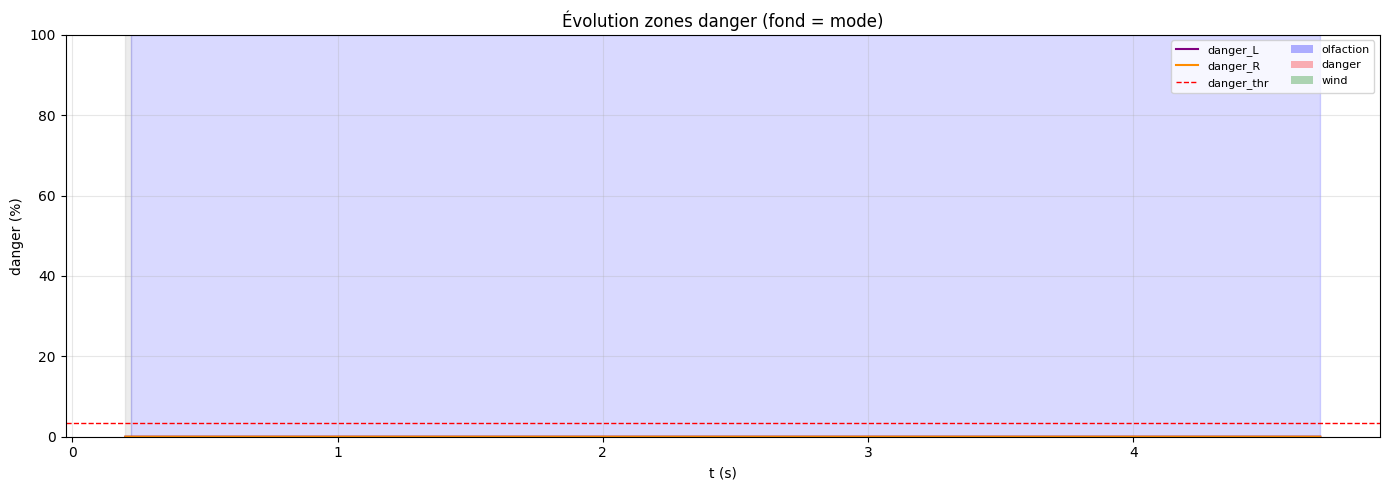

In [ ]:
%reload_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Patch
from IPython.display import display, clear_output
from tqdm import trange
from flygym.compose import ActuatorType
from miniproject.simulation import MiniprojectSimulation
from submission.controller import Controller

# ── Simulation & contrôleur ───────────────────────────────────────────────────
sim        = MiniprojectSimulation(level=0, seed=2)
controller = Controller(sim)

# ── Paramètres ────────────────────────────────────────────────────────────────
RUN_TIME        = 10.0
UPDATE_INTERVAL = 0.2
TRAJ_EVERY      = 100

n_steps = int(RUN_TIME / sim.timestep)

# ── Figure : 2x2 ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
ax_raw, ax_mask = axes[0, 0], axes[0, 1]
ax_traj, ax_area = axes[1, 0], axes[1, 1]
fig.suptitle("Vision danger override (stop) — debug live", fontsize=12)

trajectory       = []
traj_modes       = []
last_update_time = 0.0

log_t       = []
log_dangerL = []
log_dangerR = []
log_mode    = []

mode_colors = {
    "olfaction": "blue",
    "danger":    "red",
    "wind":      "green",
}

# ── Boucle ────────────────────────────────────────────────────────────────────
for step in trange(n_steps):

    joint_angles, adhesion = controller.step(sim)
    sim.set_actuator_inputs(sim.fly.name, ActuatorType.POSITION, joint_angles)
    sim.set_actuator_inputs(sim.fly.name, ActuatorType.ADHESION, adhesion)
    sim.step()
    sim.render_as_needed()

    log_t.append(sim.mj_data.time)
    log_dangerL.append(controller._last_danger_L * 100)
    log_dangerR.append(controller._last_danger_R * 100)
    log_mode.append(controller._last_mode)

    if step % TRAJ_EVERY == 0:
        trajectory.append(sim.mj_data.body(f"{sim.fly.name}/").xpos[:2].copy())
        traj_modes.append(controller._last_mode)

    fly_pos = sim.mj_data.body(f"{sim.fly.name}/").xpos[:2]
    dist = np.linalg.norm(fly_pos - controller.target_xy)
    if dist < controller.stop_distance:
        print(f"✅ Banane atteinte à t={step * sim.timestep:.2f}s !")
        break

    current_time = sim.mj_data.time
    if current_time - last_update_time < UPDATE_INTERVAL:
        continue
    last_update_time = current_time

    # ── Préparation images ──
    raw_vision = sim.get_raw_vision(sim.fly.name)
    im_raw = np.concatenate(raw_vision, axis=1)

    masks = []
    for img in raw_vision:
        H, W, _ = img.shape
        roi_mask = np.zeros((H, W), dtype=bool)
        r = img[..., 0].astype(float)
        g = img[..., 1].astype(float)
        b = img[..., 2].astype(float)
        brightness = (r + g + b) / 3
        grass_full = (
            (g > 50) & (g > 1.25 * r) & (g > 1.25 * b) & (brightness > 40)
        )
        roi_mask[int(H * controller.roi_top):int(H * controller.roi_bottom), :] = True
        masks.append((grass_full & roi_mask).astype(np.uint8) * 255)
    im_mask = np.concatenate(masks, axis=1)

    drive = controller._last_control_signal
    mode  = controller._last_mode
    hold  = controller.danger_hold

    for ax in (ax_raw, ax_mask, ax_traj, ax_area):
        ax.clear()

    # Raw
    ax_raw.imshow(im_raw)
    ax_raw.set_title(
        f"t={current_time:.1f}s | mode={mode} | hold={hold} | "
        f"drive=[{drive[0]:+.2f}, {drive[1]:+.2f}] | dist={dist:.1f}mm"
    )
    ax_raw.axis("off")

    # Mask + zones danger (bord interne de chaque œil)
    ax_mask.imshow(im_mask, cmap="gray", vmin=0, vmax=255)
    H_m, W_concat = im_mask.shape
    W_eye = W_concat // 2
    zone_w = controller.danger_zone_width * W_eye
    y0 = int(H_m * controller.roi_top)
    h_roi = int(H_m * (controller.roi_bottom - controller.roi_top))

    # Œil gauche : bord droit (centre du champ visuel)
    rect_L = patches.Rectangle(
        (W_eye - zone_w, y0), zone_w, h_roi,
        linewidth=2, edgecolor="red", facecolor="none"
    )
    # Œil droit : bord gauche (centre du champ visuel)
    rect_R = patches.Rectangle(
        (W_eye, y0), zone_w, h_roi,
        linewidth=2, edgecolor="red", facecolor="none"
    )
    ax_mask.add_patch(rect_L)
    ax_mask.add_patch(rect_R)

    ax_mask.set_title(
        f"mask | danger L={controller._last_danger_L*100:.0f}% "
        f"R={controller._last_danger_R*100:.0f}%"
    )
    ax_mask.axis("off")

    # Trajectoire colorée par mode
    if len(trajectory) > 1:
        traj = np.array(trajectory)
        for i in range(len(traj) - 1):
            color = mode_colors.get(traj_modes[i], "black")
            ax_traj.plot(traj[i:i+2, 0], traj[i:i+2, 1], "-", color=color, lw=1.5, alpha=0.8)
        ax_traj.plot(traj[-1, 0], traj[-1, 1], "ko", markersize=10)
        ax_traj.plot(*controller.target_xy, "y*", markersize=20)
        ax_traj.set_aspect("equal")
        for m, c in mode_colors.items():
            ax_traj.plot([], [], "-", color=c, label=m)
        ax_traj.plot([], [], "y*", markersize=10, label="Banane")
        ax_traj.legend(loc="best", fontsize=8)
        ax_traj.grid(alpha=0.3)
        ax_traj.set_xlabel("x (mm)")
        ax_traj.set_ylabel("y (mm)")
        ax_traj.set_title("Trajectoire")

    # Dangers + seuil
    if len(log_t) > 1:
        ax_area.plot(log_t, log_dangerL, color="purple",     lw=1.2, label="danger_L")
        ax_area.plot(log_t, log_dangerR, color="darkorange", lw=1.2, label="danger_R")
        ax_area.axhline(controller.danger_thr * 100, color="red",
                        linestyle="--", lw=0.8, alpha=0.7,
                        label=f"danger_thr ({controller.danger_thr*100:.0f}%)")
        ax_area.set_xlabel("t (s)")
        ax_area.set_ylabel("danger (%)")
        ax_area.set_ylim(0, 100)
        ax_area.set_title("Zones danger frontales")
        ax_area.legend(loc="upper left", fontsize=7, ncol=2)
        ax_area.grid(alpha=0.3)

    clear_output(wait=True)
    display(fig)

plt.close(fig)
sim.renderer.show_in_notebook()

# ── Plot final : dangers + bandes de mode ─────────────────────────────────────
fig2, ax = plt.subplots(figsize=(14, 5))
log_t_np  = np.array(log_t)
log_dL_np = np.array(log_dangerL)
log_dR_np = np.array(log_dangerR)

prev_mode = log_mode[0]
seg_start = log_t_np[0]
for i in range(1, len(log_mode)):
    if log_mode[i] != prev_mode:
        ax.axvspan(seg_start, log_t_np[i],
                   color=mode_colors.get(prev_mode, "gray"), alpha=0.15)
        seg_start = log_t_np[i]
        prev_mode = log_mode[i]
ax.axvspan(seg_start, log_t_np[-1],
           color=mode_colors.get(prev_mode, "gray"), alpha=0.15)

ax.plot(log_t_np, log_dL_np, color="purple",     lw=1.5, label="danger_L")
ax.plot(log_t_np, log_dR_np, color="darkorange", lw=1.5, label="danger_R")
ax.axhline(controller.danger_thr * 100, color="red", linestyle="--", lw=1, label="danger_thr")

mode_patches = [Patch(facecolor=c, alpha=0.3, label=m) for m, c in mode_colors.items()]
ax.legend(handles=[*ax.get_lines(), *mode_patches], loc="upper right", fontsize=8, ncol=2)

ax.set_xlabel("t (s)")
ax.set_ylabel("danger (%)")
ax.set_ylim(0, 100)
ax.set_title("Évolution zones danger (fond = mode)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
%reload_ext autoreload
%autoreload 2

import numpy as np
from tqdm import trange
from flygym.compose import ActuatorType
from miniproject.simulation import MiniprojectSimulation
from submission.controller import Controller


# === DIAGNOSTIC OLFACTION (à supprimer après debug) ===
sim_diag = MiniprojectSimulation(level=2, seed=42)
sim_diag.step()  # 1 step pour initialiser
odor_diag = sim_diag.get_olfaction(sim_diag.fly.name)
fly_pos_diag = sim_diag.mj_data.body(f'{sim_diag.fly.name}/').xpos[:2]
banana_pos_diag = np.array(sim_diag.world.banana_xy)

print("=== Diagnostic olfaction ===")
print(f"Shape       : {odor_diag.shape}")
print(f"Valeurs     : {odor_diag}")
print(f"Min         : {odor_diag.min():.6e}")
print(f"Max         : {odor_diag.max():.6e}")
print(f"Sum         : {odor_diag.sum():.6e}")
print(f"Position fly    : {fly_pos_diag}")
print(f"Position banane : {banana_pos_diag}")
print(f"Distance fly → banane : {np.linalg.norm(fly_pos_diag - banana_pos_diag):.2f} mm")
del sim_diag
print()


# === Simulation principale ===
sim = MiniprojectSimulation(level=0, seed=42)
controller = Controller(sim)

print(f"🍌 Banane en : {sim.world.banana_xy}")
print()

for step in trange(100000):
    joint_angles, adhesion = controller.step(sim)
    sim.set_actuator_inputs(sim.fly.name, ActuatorType.POSITION, joint_angles)
    sim.set_actuator_inputs(sim.fly.name, ActuatorType.ADHESION, adhesion)
    sim.step()
    sim.render_as_needed()

print(f"Position finale : {sim.mj_data.body(f'{sim.fly.name}/').xpos[:2]}")

sim.renderer.show_in_notebook()

In [ ]:
%reload_ext autoreload
%autoreload 2
 
import numpy as np
from tqdm import trange
from flygym.compose import ActuatorType
from miniproject.simulation import MiniprojectSimulation
from submission.controller import Controller
 
# ── Paramètres ────────────────────────────────────────────────────────────────
SEEDS    = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
LEVEL    = 2
RUN_TIME = 10.0   # secondes max par run
 
 
def run_seed(seed):
    """Exécute un run complet pour une seed. Retourne un dict de résultats."""
    sim = MiniprojectSimulation(level=LEVEL, seed=seed)
    controller = Controller(sim)
 
    target_xy = np.array(sim.world.banana_xy)
    n_steps = int(RUN_TIME / sim.timestep)
 
    reached = False
    reach_time = None
 
    for step in range(n_steps):
        joint_angles, adhesion = controller.step(sim)
        sim.set_actuator_inputs(sim.fly.name, ActuatorType.POSITION, joint_angles)
        sim.set_actuator_inputs(sim.fly.name, ActuatorType.ADHESION, adhesion)
        sim.step()
        # pas de render → beaucoup plus rapide
 
        fly_pos = sim.mj_data.body(f"{sim.fly.name}/").xpos[:2]
        dist = np.linalg.norm(fly_pos - target_xy)
        if dist < controller.stop_distance:
            reached = True
            reach_time = step * sim.timestep
            break
 
    final_pos = sim.mj_data.body(f"{sim.fly.name}/").xpos[:2].copy()
    final_dist = np.linalg.norm(final_pos - target_xy)
 
    return {
        "seed": seed,
        "reached": reached,
        "time": reach_time,
        "final_dist": final_dist,
        "final_pos": final_pos,
    }
 
 
# ── Boucle sur les seeds ──────────────────────────────────────────────────────
results = []
for seed in SEEDS:
    res = run_seed(seed)
    results.append(res)
    status = "✅" if res["reached"] else "❌"
    t_str = f"{res['time']:.2f}s" if res["reached"] else "  —  "
    print(
        f"{status} seed={seed:2d} | atteint={res['reached']!s:5} | "
        f"t={t_str} | dist_finale={res['final_dist']:6.2f}mm"
    )
 
# ── Résumé ────────────────────────────────────────────────────────────────────
n_total   = len(results)
n_success = sum(r["reached"] for r in results)
times     = [r["time"] for r in results if r["reached"]]
dists     = [r["final_dist"] for r in results]
 
print("\n" + "═" * 50)
print(f"Succès : {n_success}/{n_total} ({100 * n_success / n_total:.0f}%)")
if times:
    print(f"Temps (succès) : moy={np.mean(times):.2f}s | "
          f"min={np.min(times):.2f}s | max={np.max(times):.2f}s")
print(f"Distance finale : moy={np.mean(dists):.2f}mm | "
      f"min={np.min(dists):.2f}mm | max={np.max(dists):.2f}mm")
print("═" * 50)